# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

G = 6.6743*10**-11
g = 9.81
M_e = 5.972*10**24
M_m = 7.35*10**22
R_e = 6378100
R_m = 1738100
RR_e = 7.272*10**-5
test_mass = 1.0

In [121]:
time = np.sqrt(2*4000/g)
print(f"Time for test mass to fall 4km: {time} seconds")

Time for test mass to fall 4km: 28.55686245854129 seconds


$$
v = \frac{dy}{dt}
$$

$$
\frac{dv}{dt} = -g + \alpha \left| v \right|^{\gamma}
\tag{1}
$$

In the code below, D[0] represents the velocity and s[1] represents the derivative with respect to. These values are used in the equation below, where D[1] represent the derivative of velocity.

Impact time: 28.5568624585413 s
Time difference: 1.0658141036401503e-14 s


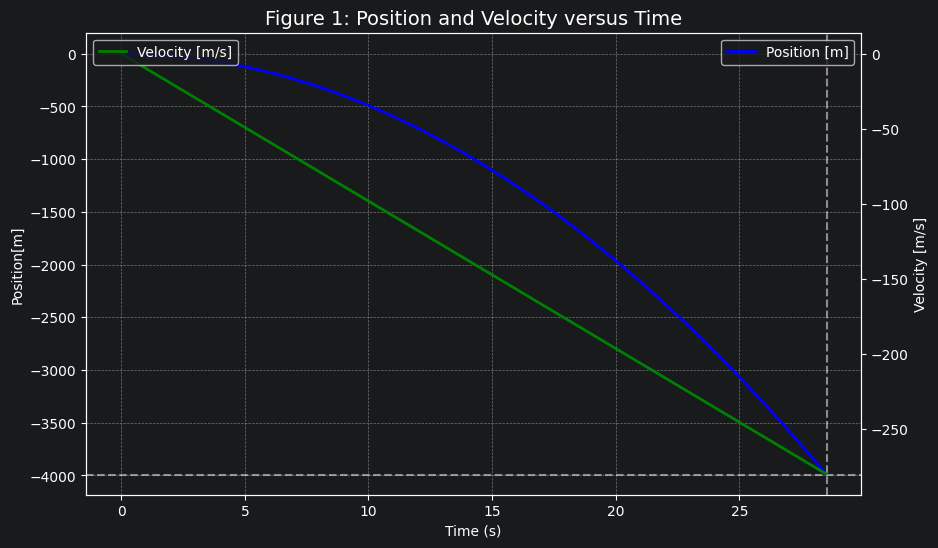

In [122]:
alpha = 0
gamma = 0

def derivatives(t, s):
    D = np.zeros(2)

    D[0] = s[1]

    D[1] = -g + alpha * np.abs(s[1])**gamma

    return D

def bottom(t, s):
    return s[0] + 4000
bottom.terminal = True
bottom.direction = -1


time_range = (0, 30)
s_initial = [0, 0]
time_grid = np.linspace(0, 30, 500)

solution = solve_ivp(fun=derivatives, t_span=time_range, y0=s_initial, t_eval=time_grid, events = bottom)

if solution.t_events[0].size > 0:
    t_impact = solution.t_events[0][0]
    print(f"Impact time: {t_impact} s")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(solution.t, solution.y[0], label='Position [m]', color='blue', linewidth=2)

ax1 = ax.twinx()

ax1.plot(solution.t, solution.y[1], label='Velocity [m/s]', color='green', linewidth=2)

ax.set_title('Figure 1: Position and Velocity versus Time', fontsize=14)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position[m]')
ax1.set_ylabel('Velocity [m/s]')

ax.grid(True, linestyle='--', alpha=0.6)

ax.axhline(y = -4000, color = "white", linestyle = "--", alpha = 0.5)
ax.axvline(x = t_impact, color = "white", linestyle = "--", alpha = 0.5)
ax.legend(loc = 'upper right')
ax1.legend(loc = 'upper left')

#Difference between the Impact time calculated using solve_ivp and kinematics
difference = t_impact - time
print (f"Time difference: {difference} s")

The difference between the time calculated to hit the bottom using simple kinematics and the time of impact using the solve_ivp events detection capability was basically negligible, as it was to the order -15. This makes sense, because we are neglecting drag and the speed dependence on the drag. That difference itself not being exactly 0 is only because of floating point precision and the rounding errors related to it.

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Impact time: 28.558355111904834 s
0.0014926533635346573


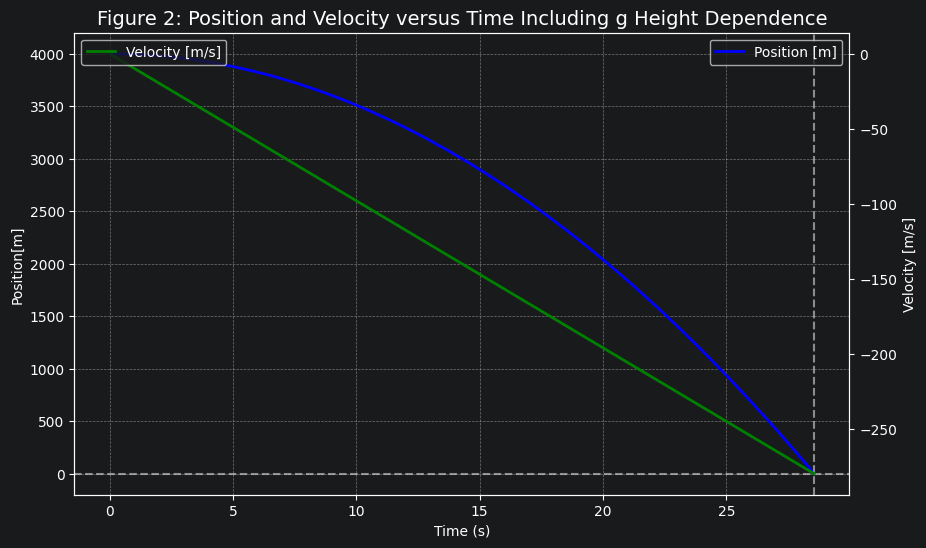

In [123]:

def updated_gravitation(r):
    g_r = g*(r/R_e)
    return g_r

def derivatives(t, s):
    D = np.zeros(2)

    D[0] = s[1]

    D[1] = -updated_gravitation(s[0]) + alpha * np.abs(s[1])**gamma*np.sign(s[1])

    return D

def bottom(t, s):
    return s[0] - (R_e - 4000)
bottom.terminal = True
bottom.direction = -1


time_range = (0, 30)
s_initial = [R_e, 0]
time_grid = np.linspace(0, 30, 500)

solution = solve_ivp(fun=derivatives, t_span=time_range, y0=s_initial, t_eval=time_grid, events = bottom)

if solution.t_events[0].size > 0:
    t_impact_vary = solution.t_events[0][0]
    print(f"Impact time: {t_impact_vary} s")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(solution.t, solution.y[0] - (R_e - 4000), label='Position [m]', color='blue', linewidth=2)
ax1 = ax.twinx()

ax1.plot(solution.t, solution.y[1], label='Velocity [m/s]', color='green', linewidth=2)

ax.set_title('Figure 2: Position and Velocity versus Time Including g Height Dependence', fontsize=14)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position[m]')
ax1.set_ylabel('Velocity [m/s]')

ax.grid(True, linestyle='--', alpha=0.6)

ax.axhline(y = 0, color = "white", linestyle = "--", alpha = 0.5)
ax.axvline(x = t_impact_vary, color = "white", linestyle = "--", alpha = 0.5)
ax.legend(loc = 'upper right')
ax1.legend(loc = 'upper left')

difference_vary = t_impact_vary-t_impact
print(difference_vary)

The difference between the impact time that took into account a changing acceleration due to gravity and the one that didn't is a non negligible but small difference of about 0.00149 seconds. The reason for why this makes sense is because, as the mass falls towards the end of the shaft, the value of the acceleration due to gravity becomes smaller. Due to this, it takes slightly longer to fall to the bottom of the shaft. When we turn on drag, we can see below that the time it takes the mass to fall the same distance is much greater because the mass reaches terminal velocity.

Impact time: 83.54308278261504 s
Difference between drag time and non drag time: 54.98622032407374


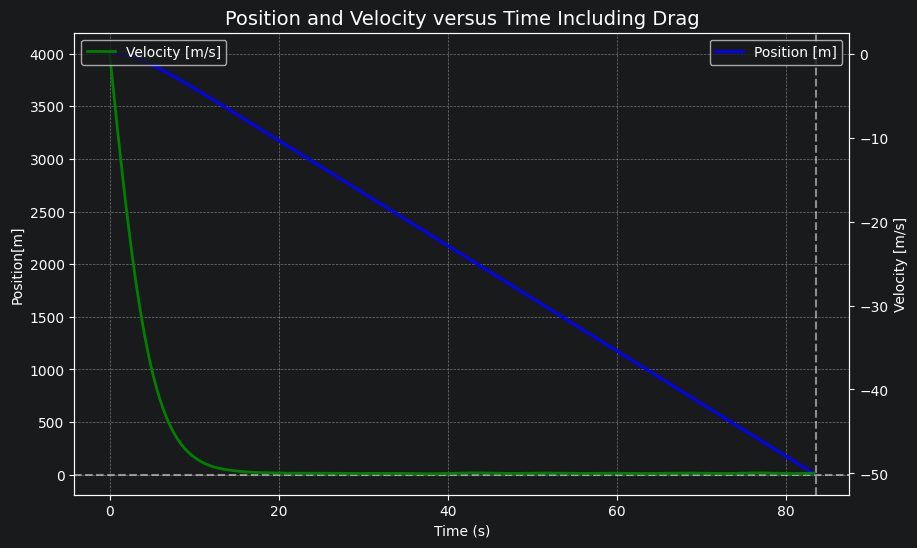

In [124]:
gamma = 2.0
alpha = g/50.0**gamma

def updated_gravitation(r):
    g_r = g*(r/R_e)
    return g_r

def derivatives(t, s):
    D = np.zeros(2)

    D[0] = s[1]

    D[1] = -updated_gravitation(s[0]) + alpha * np.abs(s[1])**gamma

    return D

def bottom(t, s):
    return s[0] - (R_e - 4000)
bottom.terminal = True
bottom.direction = -1

time_range = (0, 100)
s_initial = [R_e, 0]
time_grid = np.linspace(0, 100, 500)

solution = solve_ivp(fun=derivatives, t_span=time_range, y0=s_initial, t_eval=time_grid, events = bottom)

if solution.t_events[0].size > 0:
    t_impact_vary = solution.t_events[0][0]
    print(f"Impact time: {t_impact_vary} s")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(solution.t, solution.y[0] - (R_e - 4000), label='Position [m]', color='blue', linewidth=2)
ax1 = ax.twinx()

ax1.plot(solution.t, solution.y[1], label='Velocity [m/s]', color='green', linewidth=2)

ax.set_title('Position and Velocity versus Time Including Drag', fontsize=14)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position[m]')
ax1.set_ylabel('Velocity [m/s]')

ax.grid(True, linestyle='--', alpha=0.6)

ax.axhline(y = 0, color = "white", linestyle = "--", alpha = 0.5)
ax.axvline(x = t_impact_vary, color = "white", linestyle = "--", alpha = 0.5)
ax.legend(loc = 'upper right')
ax1.legend(loc = 'upper left')

difference_vary = t_impact_vary-t_impact
print(f"Difference between drag time and non drag time: {difference_vary}")

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




These are the updated differential equations

$$\frac{dx}{dt} = v_{x}$$
$$\frac{dv_{x}}{dt} = 2\Omega_{e}v_{y}$$
$$\frac{dy}{dt} = v_{y}$$
$$\frac{dv_{y}}{dt} = g(y) - 2\Omega v_{x} - \alpha v_{y}^{\gamma}$$

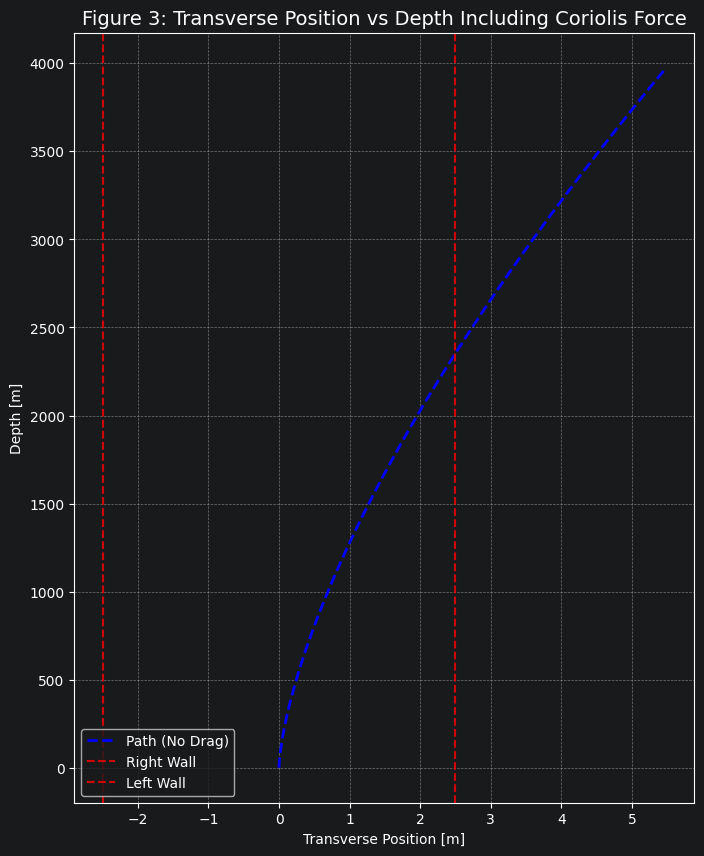

In [125]:
def updated_gravitation(y):
    r = R_e - y
    return g * (r / R_e)

def derivatives_coriolis(t, s):
    D = np.zeros(4)
    D[0] = s[1]
    D[1] = 2 * RR_e * s[3]
    D[2] = s[3]
    D[3] = updated_gravitation(s[2]) - 2 * RR_e * s[1] - alpha * (s[3]**gamma)
    return D

s_initial_coriolis = [0, 0, 0, 0]

def bottom_coriolis(t, s):
    return s[2] - 4000
bottom_coriolis.terminal = True
bottom_coriolis.direction = 1

def hit_wall(t, s):
    return s[0] - 2.5
hit_wall.terminal = False
hit_wall.direction = 1

alpha = 0
gamma = 0

time_range = (0, 120)
time_grid = np.linspace(0, 120, 1000)

solution = solve_ivp(
    fun=derivatives_coriolis,
    t_span=time_range,
    y0=s_initial_coriolis,
    t_eval=time_grid,
    events=[bottom_coriolis, hit_wall]
)

depth = solution.y[2]
transverse = solution.y[0]

fig, ax = plt.subplots(figsize=(8, 10))

ax.plot(transverse, depth, color='blue', linestyle='--', linewidth=2, label='Path (No Drag)')

ax.set_title('Figure 3: Transverse Position vs Depth Including Coriolis Force', fontsize=14)
ax.set_xlabel('Transverse Position [m]')
ax.set_ylabel('Depth [m]')
ax.axvline(x=2.5,  color='red', linestyle='--', alpha=0.8, label='Right Wall')
ax.axvline(x=-2.5, color='red', linestyle='--', alpha=0.8, label='Left Wall')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='lower left')

When the mine shaft is 5m wide, we notice from the graph that the transverse position ends up crossing 2.5m line. Due to the fact we assumed the mass starts falling from the center of the shaft, taking into account the coriolis force, the mass ends up hitting the right wall. In the plot below, the drag force really does make a difference, because we can see that the mass hit the right wall at a smaller depth than without drag. The reason why is, because the mass reaches terminal velocity and ends up falling much more slowly. Due to this, the coriolis force, has more time for it to push it to the right wall, and we see that that effect dominates and pushes the mass to the rightmost wall at around a depth of 1300m.

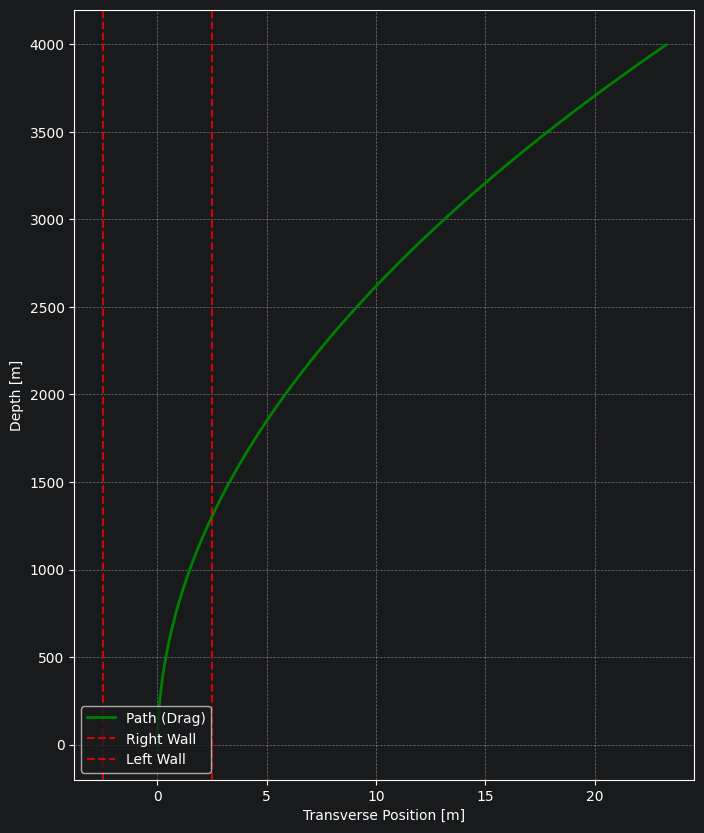

In [126]:
gamma = 2.0
alpha = g / 50.0**gamma

solution_drag = solve_ivp(
    fun=derivatives_coriolis,
    t_span=time_range,
    y0=s_initial_coriolis,
    t_eval=time_grid,
    events=[bottom_coriolis, hit_wall]
)

depth_drag = solution_drag.y[2]        # no - R_e needed
transverse_drag = solution_drag.y[0]

fig, ax = plt.subplots(figsize=(8, 10))

ax.plot(transverse_drag, depth_drag, color='green', linewidth=2, label='Path (Drag)')
ax.set_xlabel('Transverse Position [m]')
ax.set_ylabel('Depth [m]')
ax.axvline(x=2.5,  color='red', linestyle='--', alpha=0.8, label='Right Wall')
ax.axvline(x=-2.5, color='red', linestyle='--', alpha=0.8, label='Left Wall')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='lower left')

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.
                In your notebook, label this figure clearly as **Figure 4**.

2. How long will it take for the object to reach the other side?
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and
                Earth mass $M$.





Time to reach center: 1266.5 seconds
Max Speed at center: 7910.5 m/s
Time to reach other side: 2532.6 seconds
Depth at other side: 12758610.2 m (Exact diameter: 12756200 m)
Theoretical Orbital Period: 5066.3 seconds
Difference of Orbital Period to Crossing Time: 2533.71


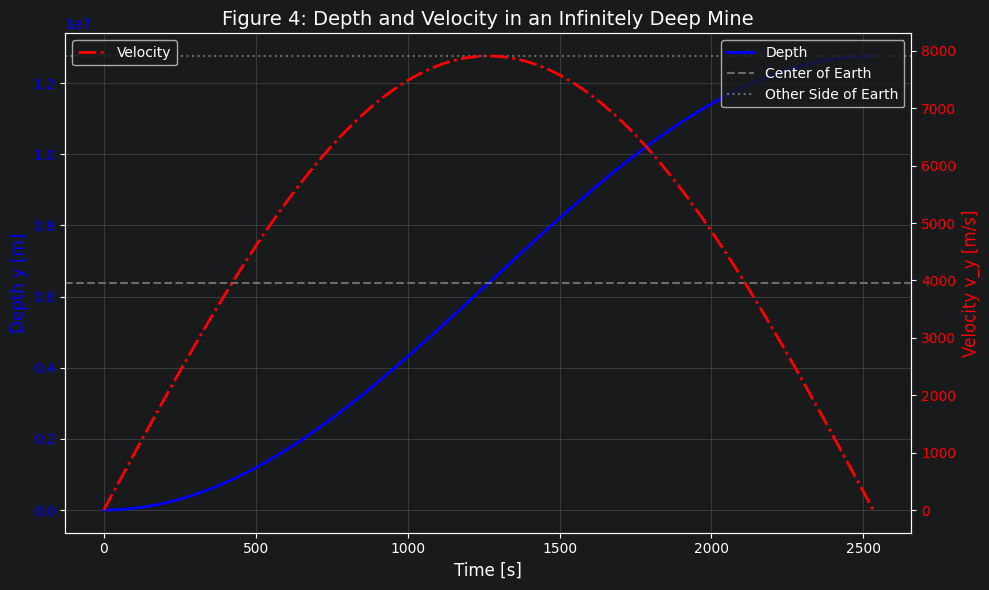

In [127]:
def derivatives_inf_mine(t, s):
    D = np.zeros(2)
    D[0] = s[1]
    D[1] = updated_gravitation(s[0])
    return D

def center(t, s):
    return s[0] - R_e
center.terminal = False
center.direction = 1

def other_side(t, s):
    return s[1]
other_side.terminal = True
other_side.direction = -1

s_initial = [0.0, 0.0]
t_span = (0, 6000)
t_eval = np.linspace(0, 5000, 2000)

solution = solve_ivp(
    fun=derivatives_inf_mine,
    t_span=t_span,
    y0=s_initial,
    t_eval=t_eval,
    events=[center, other_side]
)

t = solution.t
y = solution.y[0]
vy = solution.y[1]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Depth on primary Y-axis
ax1.set_xlabel('Time [s]', fontsize=12)
ax1.set_ylabel('Depth y [m]', color="blue", fontsize=12)
ax1.plot(t, y, color="blue", linewidth=2, label='Depth')
ax1.tick_params(axis='y', labelcolor="blue")

ax1.axhline(R_e, color='gray', linestyle='--', alpha=0.8, label='Center of Earth')
ax1.axhline(2*R_e, color='gray', linestyle=':', alpha=0.8, label='Other Side of Earth')

ax2 = ax1.twinx()
ax2.set_ylabel('Velocity v_y [m/s]', color="red", fontsize=12)
ax2.plot(t, vy, color="red", linewidth=2, linestyle='-.', label='Velocity')
ax2.tick_params(axis='y', labelcolor="red")


ax1.legend(loc='upper right')
ax2.legend(loc='upper left')

ax1.set_title('Figure 4: Depth and Velocity in an Infinitely Deep Mine', fontsize=14)
ax1.grid(True, alpha=0.3)
fig.tight_layout()

center_time = solution.t_events[0][0]
center_speed = solution.y_events[0][0][1]

other_side_time = solution.t_events[1][0]
other_side_depth = solution.y_events[1][0][0]

orbital_period = 2 * np.pi * np.sqrt(R_e / g)

print(f"Time to reach center: {center_time:.1f} seconds")
print(f"Max Speed at center: {center_speed:.1f} m/s")
print(f"Time to reach other side: {other_side_time:.1f} seconds")
print(f"Depth at other side: {other_side_depth:.1f} m (Exact diameter: {2*R_e} m)")
print(f"Theoretical Orbital Period: {orbital_period:.1f} seconds")
print(f"Difference of Orbital Period to Crossing Time: {orbital_period - other_side_time:.2f}")

In the graph, you can see that the velocity of the graph goes up to its maximum value at the center and then goes to zero again. Physically, this would make sense, because the acceleration due to gravity is zero at the center of the earth, but the momentum of the mass is maximum, causing it to exhibit that radial orbital motion. One can also see this pattern of motion exhibited in how the slopes of the depth graph changes. The difference in the time to reach the other side differs by 2533.71 seconds, compared to the theoretical orbital period. The reason why is because the time to the other side only measures half the time it takes to complete that radial orbit while the theoretical orbital period measures the total time some object takes to go around the earth when it is right on the surface. So the time difference is exactly half.

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

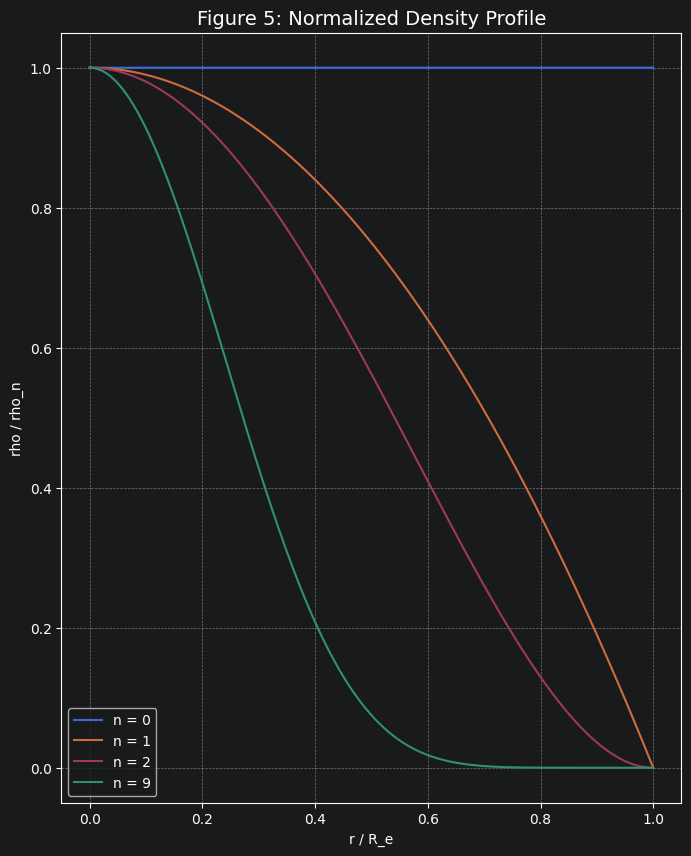

In [128]:
from scipy.integrate import quad

r_values = np.linspace(0, R_e, 2000)

fig, ax = plt.subplots(figsize=(8, 10))

for n in [0, 1, 2, 9]:
    rho_normalized = (1 - (r_values**2 / R_e**2))**n
    ax.plot(r_values / R_e, rho_normalized, label= f"n = {n}")

ax.set_title('Figure 5: Normalized Density Profile', fontsize=14)
ax.set_xlabel('r / R_e')
ax.set_ylabel('rho / rho_n')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

### Part 5, Section B (Forces)

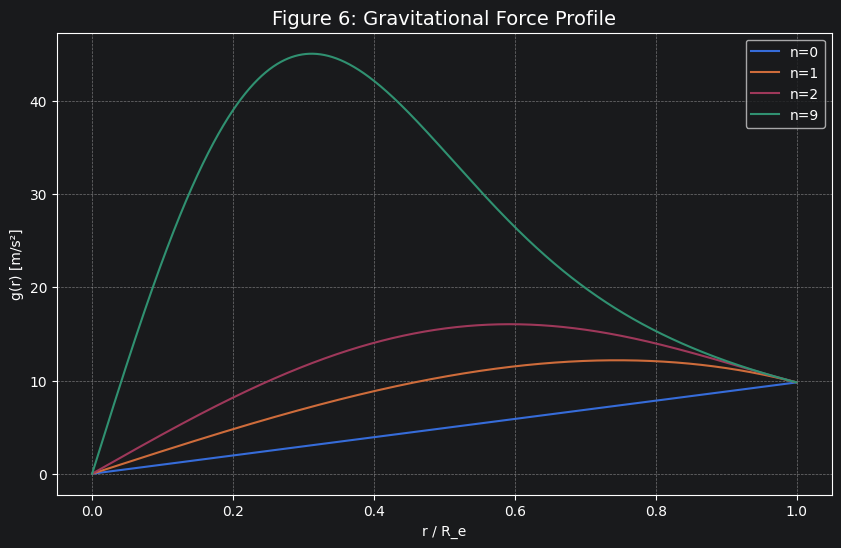

In [129]:
def rho(n):
    function_1 = lambda r: 4 * np.pi * (1 - (r**2 / R_e**2))**n * r**2
    integral, err = quad(function_1, 0, R_e)
    return M_e / integral

def g_nonuniform(r, n, rho):
    if r == 0:
        return 0
    function_2 = lambda rp: 4 * np.pi * rho * (1 - (rp**2 / R_e**2))**n * rp**2
    M_r, err = quad(function_2, 0, r)
    return G * M_r / r**2

fig, ax = plt.subplots(figsize=(10, 6))

for n in [0, 1, 2, 9]:
    rho_n = rho(n)
    g_values = []
    for r in r_values:
        g_values.append(g_nonuniform(r, n, rho_n))
    ax.plot(r_values / R_e, g_values, label=f'n={n}')

ax.set_title('Figure 6: Gravitational Force Profile', fontsize=14)
ax.set_xlabel('r / R_e')
ax.set_ylabel('g(r) [m/s²]')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

### Part 5, Section C (Equations of Motion

In this section, I plotted the graphs only until the center of the Earth, but in the Fourier Transform question, I took into account the whole periodic motion.

n=0: Time to center = 1267.228228873086 seconds, Speed at center = 7905.676404484275 m/s
n=1: Time to center = 1096.5094366431479 seconds, Speed at center = 10462.05739911341 m/s
n=2: Time to center = 1035.1519832753604 seconds, Speed at center = 12202.145443308376 m/s
n=9: Time to center = 943.8415123901534 seconds, Speed at center = 18393.453606815157 m/s


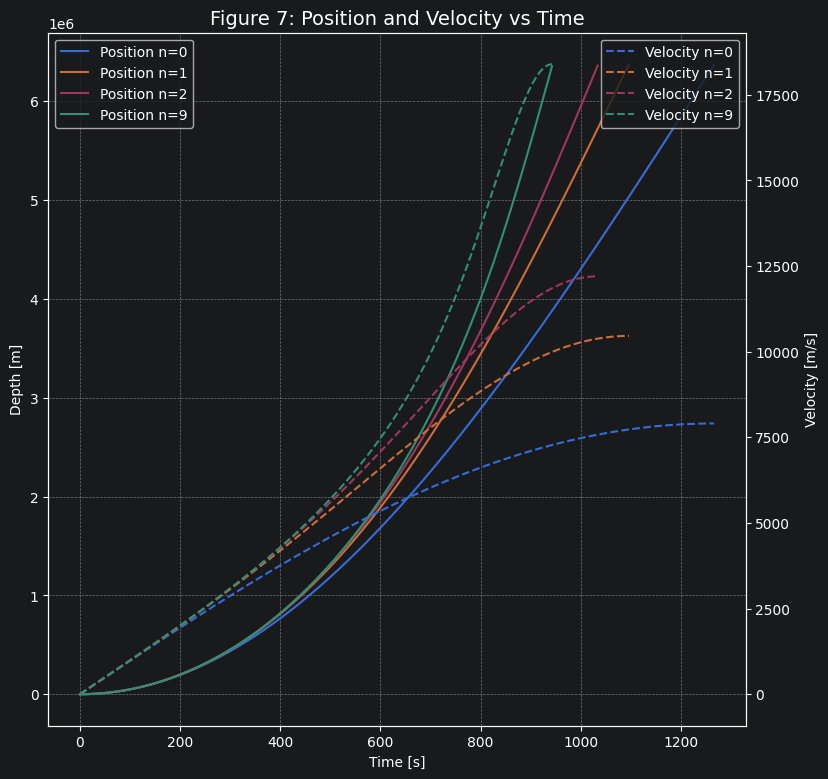

In [130]:
fig, ax = plt.subplots(figsize=(9, 9))
ax1 = ax.twinx()

for n in [0, 1, 2, 9]:
    rho_n = rho(n)

    def derivatives_nonuniform_density(t, s, n=n, rho_n=rho_n):
        D = np.zeros(2)
        D[0] = s[1]
        r = R_e - s[0]
        D[1] = g_nonuniform(r, n, rho_n)
        return D

    def bottom_nonuniform_density(t, s):
        return s[0] - R_e
    bottom_nonuniform_density.terminal = True
    bottom_nonuniform_density.direction = 1

    sol = solve_ivp(
        fun=derivatives_nonuniform_density,
        t_span=(0, 8000),
        y0=[0, 0],
        t_eval=np.linspace(0, 8000, 5000),
        events=bottom_nonuniform_density
    )

    ax.plot(sol.t, sol.y[0], label=f'Position n={n}')
    ax1.plot(sol.t, sol.y[1], linestyle='--', label=f'Velocity n={n}')

    t_center = sol.t_events[0][0]
    v_center = sol.y_events[0][0][1]
    print(f"n={n}: Time to center = {t_center} seconds, Speed at center = {v_center} m/s")

ax.set_title('Figure 7: Position and Velocity vs Time', fontsize=14)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Depth [m]')
ax1.set_ylabel('Velocity [m/s]')
ax.legend(loc='upper left')
ax1.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


$$\rho = \frac{M}{\frac{4}{3}\pi R^3}$$

$$M = \frac{4}{3}\pi R^3 \rho$$

$$g_0 = \frac{GM}{R^2} = \frac{4}{3}\pi G R \rho$$

$$a = -\frac{g_0}{R}r = -\frac{4}{3}\pi G \rho \cdot r$$

This situation is similar to simple harmonic motion, so $ a = -\omega^2$:

$$\omega^2 = \frac{4}{3}\pi G \rho$$

$$\omega = \sqrt{\frac{4}{3}\pi G \rho}$$

The period of simple harmonic motion is:

$$T = \frac{2\pi}{\omega} = \frac{2\pi}{\sqrt{\frac{4}{3}\pi G \rho}} = 2\pi\sqrt{\frac{3}{4\pi G \rho}}$$

The fall time to the center is one fourth the period:

$$t = \frac{T}{4} = \frac{\pi}{2}\sqrt{\frac{3}{4\pi G \rho}}$$

$$t = \frac{\pi}{2}\sqrt{\frac{R}{g_0}} = \frac{\pi}{2}\sqrt{\frac{R}{\frac{4}{3}\pi G R \rho}} = \frac{\pi}{2}\sqrt{\frac{3}{4\pi G \rho}}$$

$$\boxed{t = \frac{\pi}{2}\sqrt{\frac{3}{4\pi G \rho}}}$$

In [131]:
rho_earth = M_e / (4/3 * np.pi * R_e**3)
rho_moon = M_m / (4/3 * np.pi * R_m**3)

g_m = G * M_m / R_m**2
print(f"The moon's surface gravity: {g_m:.4f} m/s^2")

t_moon_theoretical = (np.pi / 2) * np.sqrt(3/ (4*np.pi*G*rho_moon))
print(f"Theoretical fall time to Moon center: {t_moon_theoretical:.4f} s")

t_from_density = (np.pi/2) * np.sqrt(3 / (4 * G *np.pi*rho_moon))
print(f"Fall time from density formula: {t_from_density:.4f} s")

The moon's surface gravity: 1.6238 m/s^2
Theoretical fall time to Moon center: 1625.1202 s
Fall time from density formula: 1625.1202 s


In [132]:
def derivatives_moon(t, s):
    D = np.zeros(2)
    D[0] = s[1]
    r = R_m - s[0]
    D[1] = g_m * (r / R_m)
    return D

def bottom_moon(t, s):
    return s[0] - R_m
bottom_moon.terminal = True
bottom_moon.direction = 1

sol_moon = solve_ivp(
    fun=derivatives_moon,
    t_span=(0, 8000),
    y0=[0, 0],
    t_eval=np.linspace(0, 8000, 5000),
    events=bottom_moon
)

t_moon_center = sol_moon.t_events[0][0]
v_moon_center = sol_moon.y_events[0][0][1]

print(f"Time to the center of the Earth for n=0 was 1267.228228873086 seconds")
print(f"Fall time to the center of the Moon: {t_moon_center} s")
print(f"Speed at the center of the Moon: {v_moon_center} m/s")

print(f"Earth density: {rho_earth} kg/m^3")
print(f"Moon density: {rho_moon} kg/m^3")
print(f"Difference in the Earth and Moon densities: {abs(rho_earth - rho_moon)} kg/m^3")
print(f"Difference in the earth and Moon fall times: {abs(1267.228228873086-t_moon_center)} s")

Time to the center of the Earth for n=0 was 1267.228228873086 seconds
Fall time to the center of the Moon: 1624.928040239013 s
Speed at the center of the Moon: 1679.9823752129669 m/s
Earth density: 5494.867409551201 kg/m^3
Moon density: 3341.753803870318 kg/m^3
Difference in the Earth and Moon densities: 2153.1136056808828 kg/m^3
Difference in the earth and Moon fall times: 357.69981136592696 s


The fall/orbit time depends inversely with density, and this makes sense. When the density of the body increases (more mass concentrated in a volume), meaning that the acceleration due to gravity of that mass will increase. Due to this, the fall time to the center of the Earth will decrease overall. In the case of the Earth and the Moon, because the Moon has a lower density than the moon, the acceleration due to gravity is relatively smaller than that of the Earth. Therefore, the time it takes for the mass to fall down to the center of a lunar shaft will be longer than on the Earth.

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

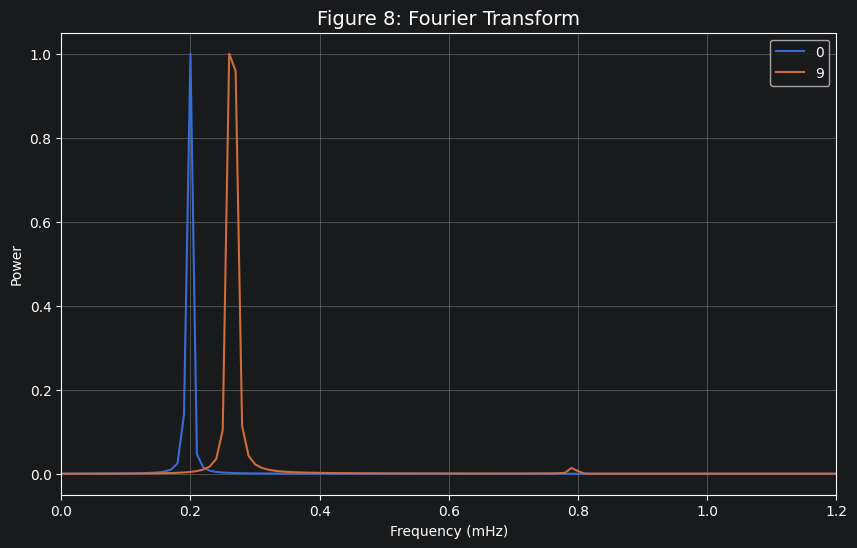

In [133]:
from numpy.fft import rfft, rfftfreq

time_span = [0, 100000]
time_eval = np.linspace(0, 100000, 50000)
dt = time_eval[1] - time_eval[0]

n_vals = [0, 9]
fig, ax = plt.subplots(figsize=(10, 6))

for n in n_vals:
    rho_n = rho(n)

    def derivatives_nonuniform(t, s, n=n, rho_n=rho_n):
        D = np.zeros(2)
        D[0] = s[1]
        r = abs(s[0])
        D[1] = -g_nonuniform(r, n, rho_n) * np.sign(s[0])
        return D

    sol = solve_ivp(derivatives_nonuniform, time_span, [R_e, 0], t_eval=time_eval, max_step=10)

    signal = sol.y[0]
    signal = signal - np.mean(signal)   # remove DC offset

    F = np.fft.rfft(signal)
    frequencies = np.fft.rfftfreq(len(signal), dt)
    power = np.abs(F)**2

    ax.plot(frequencies * 1000, power / np.max(power), label=f"{n}")

ax.set_xlim(0, 1.2)
ax.set_xlabel("Frequency (mHz)")
ax.set_ylabel("Power")
ax.set_title("Figure 8: Fourier Transform", fontsize=14)
ax.legend(loc='upper right')
ax.grid(True)

Describe what we see here: We see a peak at the respective frequencies for n=0 and 9, because we are looking at a simple harmonic motion. When the mass falls back and forth, the force due to gravity behaves analogous to that of a restoring spring force or pendulum force, so we can model the motion like a sinusoid. This is why it makes sense to see each of the individual graphs peaked at one frequency. We can see that the n=0 case peaks at a lower frequency than the n=9 case, because the lower density of the earth causes the period to be longer, therefore the frequency to be smaller (the gravitational force isn't as strong in the center due to a smaller concentrated mass). Using this reasoning, we can also see why the n=9 case has a higher frequency.